# Financial Named Entity Recognition (NER) Fine-Tuning

**Chapter 10: From Text to Features - The Transformer Breakthrough**
**Section Reference**: See Section 10.4 for Transformers and token classification

**Docker image**: `ml4t-gpu`

> **GPU recommended**: This notebook trains models with PyTorch/CUDA. It will run on CPU
> but training may be very slow. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 10_text_feature_engineering/05_financial_ner_finetuning.py
> ```


## Purpose
This notebook demonstrates how to fine-tune a Transformer for Named Entity
Recognition (NER) on financial text. NER extracts structured entities
(companies, amounts, dates) from unstructured text, enabling automated
information extraction from earnings calls, SEC filings, and news.

## Learning Objectives
After completing this notebook, you will be able to:
- Understand BIO tagging for multi-word entity annotation
- Align subword tokens with word-level labels
- Fine-tune a Transformer for token classification (NER)
- Extract entities from financial text with the trained model
- Evaluate NER performance with precision, recall, and F1

## Cross-References
- **Upstream**: `bert_finetuning.py` (fine-tuning basics), Chapter 5 (text data)
- **Downstream**: Chapter 10 (structured features from text)
- **Related**: Information extraction pipelines, knowledge graphs

In [1]:
"""Financial Named Entity Recognition Fine-Tuning — fine-tune a Transformer for NER on financial text."""

import json
import warnings
from collections import Counter

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
)
from transformers import (
    set_seed as set_transformers_seed,
)

from utils.paths import get_chapter_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

/opt/ml4t/lib/python3.14/site-packages/multiprocess/connection.py:335: SyntaxWarning: 'return' in a 'finally' block
  return f
/opt/ml4t/lib/python3.14/site-packages/multiprocess/connection.py:337: SyntaxWarning: 'return' in a 'finally' block
  return self._get_more_data(ov, maxsize)


In [2]:
SEED = 42
N_SAMPLES = 500
N_EPOCHS = 3

In [3]:
# Reproducibility — set_global_seeds covers Python random / NumPy / Torch.
# transformers Trainer uses its own RNG that needs explicit seeding.
set_global_seeds(SEED)
set_transformers_seed(SEED)

CONFIG = {
    "random_seed": SEED,
    "n_samples": N_SAMPLES,
    "n_epochs": N_EPOCHS,
    "model": {
        "base": "ProsusAI/finbert",
        "description": "FinBERT - BERT pre-trained on financial text",
    },
    "dataset": {
        "source": "synthetic (teaching-focused)",
        "schema": "IOB2 (Inside-Outside-Beginning variant 2)",
        "entity_types": ["ORG", "MONEY", "DATE", "PER", "PERCENT"],
        "note": "Synthetic data matches chapter's coarse-grained taxonomy",
    },
    "training": {
        "learning_rate": 2e-5,
        "batch_size": 16,
        "weight_decay": 0.01,
        "max_length": 128,
    },
}

print("=" * 70)
print("EXPERIMENT CONFIGURATION")
print("=" * 70)
print(json.dumps(CONFIG, indent=2))
print("=" * 70)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nUsing device: {device}")

EXPERIMENT CONFIGURATION
{
  "random_seed": 42,
  "n_samples": 500,
  "n_epochs": 3,
  "model": {
    "base": "ProsusAI/finbert",
    "description": "FinBERT - BERT pre-trained on financial text"
  },
  "dataset": {
    "source": "synthetic (teaching-focused)",
    "schema": "IOB2 (Inside-Outside-Beginning variant 2)",
    "entity_types": [
      "ORG",
      "MONEY",
      "DATE",
      "PER",
      "PERCENT"
    ],
    "note": "Synthetic data matches chapter's coarse-grained taxonomy"
  },
  "training": {
    "learning_rate": 2e-05,
    "batch_size": 16,
    "weight_decay": 0.01,
    "max_length": 128
  }
}

Using device: cuda


## 2. Generate Synthetic Financial NER Dataset

This is a teaching-focused demo: we generate synthetic financial sentences
annotated with coarse-grained entity types (the next cell builds them from a
small set of templates). For a production NER benchmark, use a real annotated
corpus such as CoNLL-2003 or FiNER-139 — the training pipeline below is
identical.

### Generate Synthetic NER Data
Create realistic financial sentences with BIO-tagged entities for training.

In [4]:
def generate_synthetic_ner_data(n_samples: int = 500, seed: int = 42):
    """Generate synthetic financial NER data for testing/demo purposes.

    Creates realistic-looking financial sentences with entity annotations.
    """
    import random

    random.seed(seed)

    # Template components
    orgs = ["Apple Inc.", "Microsoft", "Goldman Sachs", "JPMorgan Chase", "Tesla Motors"]
    people = ["Tim Cook", "Satya Nadella", "Warren Buffett", "Elon Musk", "Janet Yellen"]
    money = ["$500 million", "$1.2 billion", "$50,000", "€10 million", "£5.5 billion"]
    dates = ["Q3 2024", "March 15, 2024", "fiscal year 2023", "last quarter", "January 2025"]
    percents = ["15%", "2.5%", "10 percent", "25.7%", "3.2%"]

    templates = [
        ("{ORG}", "announced", "revenue", "of", "{MONEY}", "for", "{DATE}"),
        ("{PER}", "CEO", "of", "{ORG}", "reported", "growth", "of", "{PERCENT}"),
        ("The", "stock", "of", "{ORG}", "rose", "{PERCENT}", "on", "{DATE}"),
        ("{ORG}", "plans", "to", "invest", "{MONEY}", "in", "new", "facilities"),
        ("{PER}", "sold", "{MONEY}", "worth", "of", "{ORG}", "shares"),
    ]

    samples = []
    for _ in range(n_samples):
        template = random.choice(templates)
        tokens = []
        ner_tags = []

        for word in template:
            if word == "{ORG}":
                org = random.choice(orgs)
                org_tokens = org.split()
                tokens.extend(org_tokens)
                ner_tags.append(1)  # B-ORG
                ner_tags.extend([2] * (len(org_tokens) - 1))  # I-ORG
            elif word == "{PER}":
                per = random.choice(people)
                per_tokens = per.split()
                tokens.extend(per_tokens)
                ner_tags.append(7)  # B-PER
                ner_tags.extend([8] * (len(per_tokens) - 1))  # I-PER
            elif word == "{MONEY}":
                mon = random.choice(money)
                mon_tokens = mon.split()
                tokens.extend(mon_tokens)
                ner_tags.append(3)  # B-MONEY
                ner_tags.extend([4] * (len(mon_tokens) - 1))  # I-MONEY
            elif word == "{DATE}":
                date = random.choice(dates)
                date_tokens = date.split()
                tokens.extend(date_tokens)
                ner_tags.append(5)  # B-DATE
                ner_tags.extend([6] * (len(date_tokens) - 1))  # I-DATE
            elif word == "{PERCENT}":
                pct = random.choice(percents)
                pct_tokens = pct.split()
                tokens.extend(pct_tokens)
                ner_tags.append(9)  # B-PERCENT
                ner_tags.extend([10] * (len(pct_tokens) - 1))  # I-PERCENT
            else:
                tokens.append(word)
                ner_tags.append(0)  # O

        samples.append({"tokens": tokens, "ner_tags": ner_tags})

    return Dataset.from_list(samples)

### Load NER Dataset
Load the dataset with provenance tracking, using the synthetic data generator.

In [5]:
def load_ner_dataset():
    """Load financial NER dataset with explicit provenance tracking.

    Uses synthetic data designed to match chapter prose (coarse-grained financial
    entities: ORG, MONEY, DATE, PER, PERCENT). This provides consistent, reproducible
    results for teaching purposes.

    Returns:
        tuple: (dataset, label_list) where label_list is the BIO tag vocabulary
    """
    # Coarse-grained financial NER label scheme (matches chapter prose)
    label_list = [
        "O",  # 0: Outside
        "B-ORG",  # 1: Beginning of organization
        "I-ORG",  # 2: Inside organization
        "B-MONEY",  # 3: Beginning of monetary value
        "I-MONEY",  # 4: Inside monetary value
        "B-DATE",  # 5: Beginning of date
        "I-DATE",  # 6: Inside date
        "B-PER",  # 7: Beginning of person
        "I-PER",  # 8: Inside person
        "B-PERCENT",  # 9: Beginning of percentage
        "I-PERCENT",  # 10: Inside percentage
    ]

    print("\n" + "=" * 70)
    print("DATASET PROVENANCE")
    print("=" * 70)
    print("  Source: Synthetic financial NER data")
    print("  Purpose: Teaching BIO tagging and token classification")
    print(f"  Schema: {CONFIG['dataset']['schema']}")
    print(f"  Entity types: {CONFIG['dataset']['entity_types']}")
    print(f"  Samples: {N_SAMPLES}")
    print("\n  Note: Synthetic data provides controlled examples matching")
    print("  the chapter's coarse-grained entity taxonomy. For production")
    print("  NER, use annotated datasets like CoNLL-2003 or domain-specific")
    print("  corpora with appropriate label mappings.")
    print("=" * 70 + "\n")

    return generate_synthetic_ner_data(n_samples=N_SAMPLES, seed=SEED), label_list

In [6]:
# Load dataset and label scheme
dataset, LABEL_LIST = load_ner_dataset()

# Create label mappings from the dataset's label scheme
id2label = dict(enumerate(LABEL_LIST))
label2id = {label: i for i, label in id2label.items()}

# Train/test split
split = dataset.train_test_split(test_size=0.2, seed=SEED)
print(f"Train: {len(split['train'])}, Test: {len(split['test'])}")


DATASET PROVENANCE
  Source: Synthetic financial NER data
  Purpose: Teaching BIO tagging and token classification
  Schema: IOB2 (Inside-Outside-Beginning variant 2)
  Entity types: ['ORG', 'MONEY', 'DATE', 'PER', 'PERCENT']
  Samples: 500

  Note: Synthetic data provides controlled examples matching
  the chapter's coarse-grained entity taxonomy. For production
  NER, use annotated datasets like CoNLL-2003 or domain-specific
  corpora with appropriate label mappings.

Train: 400, Test: 100


In [7]:
# Preview data
print("\nSample tokens and tags:")
example = split["train"][0]
for token, tag in zip(example["tokens"][:10], example["ner_tags"][:10], strict=False):
    print(f"  {token:15} -> {id2label[tag]}")


Sample tokens and tags:
  Tim             -> B-PER
  Cook            -> I-PER
  CEO             -> O
  of              -> O
  Goldman         -> B-ORG
  Sachs           -> I-ORG
  reported        -> O
  growth          -> O
  of              -> O
  3.2%            -> B-PERCENT


## Tokenization for Token Classification

Token classification requires aligning labels with subword tokens.
When a word is split into multiple subwords, we assign the label
only to the first subword and use -100 (ignore) for the rest.

In [8]:
# Load tokenizer
model_name = "ProsusAI/finbert"  # Use FinBERT for financial domain
tokenizer = AutoTokenizer.from_pretrained(model_name)


def tokenize_and_align_labels(examples):
    """Tokenize and align labels with subword tokens."""
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        padding="max_length",
        max_length=128,
    )

    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                # Special tokens get -100
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                # First token of a word gets the label
                label_ids.append(label[word_idx])
            else:
                # Subsequent subwords get -100
                label_ids.append(-100)
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs


# Tokenize dataset
tokenized_dataset = split.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=split["train"].column_names,
)

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Parameter 'function'=<function tokenize_and_align_labels at 0x740a238f6b90> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only shown once. Subsequent hashing failures won't be shown.


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [9]:
# Load model
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(LABEL_LIST),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

# Data collator
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([11, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([11]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
# Metrics - try seqeval first, fall back to sklearn if not installed
try:
    seqeval = evaluate.load("seqeval")
    SEQEVAL_AVAILABLE = True
except Exception:
    SEQEVAL_AVAILABLE = False
    print("seqeval not available, using sklearn metrics fallback")
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


def compute_metrics(eval_pred):
    """Compute metrics for NER evaluation.

    Handles both tuple format (predictions, labels) and EvalPrediction object
    for compatibility across HuggingFace transformers versions.
    """
    # Handle both tuple and EvalPrediction object formats
    if hasattr(eval_pred, "predictions"):
        # EvalPrediction object
        predictions = eval_pred.predictions
        labels = eval_pred.label_ids
    else:
        # Tuple format
        predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (special tokens)
    true_predictions = [
        [LABEL_LIST[pred] for (pred, lab) in zip(prediction, label, strict=False) if lab != -100]
        for prediction, label in zip(predictions, labels, strict=False)
    ]
    true_labels = [
        [LABEL_LIST[lab] for (pred, lab) in zip(prediction, label, strict=False) if lab != -100]
        for prediction, label in zip(predictions, labels, strict=False)
    ]

    if SEQEVAL_AVAILABLE:
        results = seqeval.compute(predictions=true_predictions, references=true_labels)
        return {
            "precision": results["overall_precision"],
            "recall": results["overall_recall"],
            "f1": results["overall_f1"],
            "accuracy": results["overall_accuracy"],
        }
    else:
        # Flatten for sklearn metrics (token-level, not entity-level)
        flat_preds = [tag for seq in true_predictions for tag in seq]
        flat_labels = [tag for seq in true_labels for tag in seq]
        return {
            "precision": precision_score(
                flat_labels, flat_preds, average="weighted", zero_division=0
            ),
            "recall": recall_score(flat_labels, flat_preds, average="weighted", zero_division=0),
            "f1": f1_score(flat_labels, flat_preds, average="weighted", zero_division=0),
            "accuracy": accuracy_score(flat_labels, flat_preds),
        }

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

seqeval not available, using sklearn metrics fallback


In [11]:
# Training arguments - save checkpoints under chapter output directory
chapter_dir = get_chapter_dir(10)
output_dir = chapter_dir / "output" / "financial_ner"
output_dir.mkdir(parents=True, exist_ok=True)

# Build training arguments dict with version-compatible parameter names
# transformers 4.36+ uses eval_strategy, older versions use evaluation_strategy
import inspect

eval_strat_key = "eval_strategy"  # Default to newer API
try:
    sig = inspect.signature(TrainingArguments)
    if "evaluation_strategy" in sig.parameters and "eval_strategy" not in sig.parameters:
        eval_strat_key = "evaluation_strategy"
except Exception:
    pass  # Use defaults

training_kwargs = {
    "output_dir": str(output_dir),
    eval_strat_key: "epoch",
    "save_strategy": "epoch",
    "learning_rate": 2e-5,
    "per_device_train_batch_size": 16,
    "per_device_eval_batch_size": 16,
    "num_train_epochs": N_EPOCHS,
    "weight_decay": 0.01,
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1",
    "report_to": "none",
    "fp16": torch.cuda.is_available(),
}

training_args = TrainingArguments(**training_kwargs)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [12]:
# Train
print("Training NER model...")
trainer.train()

# Evaluate
results = trainer.evaluate()
print("\nTest Results:")
print(f"  Precision: {results['eval_precision']:.3f}")
print(f"  Recall: {results['eval_recall']:.3f}")
print(f"  F1: {results['eval_f1']:.3f}")

Training NER model...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.326837,0.978396,0.981873,0.978993,0.981873
2,No log,0.053273,1.000000,1.000000,1.000000,1.000000
3,No log,0.031435,1.000000,1.000000,1.000000,1.000000



Test Results:
  Precision: 1.000
  Recall: 1.000
  F1: 1.000


## Entity Extraction Examples

Let's see the model in action on sample financial sentences.

In [13]:
def extract_entities(text: str) -> list[tuple[str, str]]:
    """Extract named entities from text using the fine-tuned model."""
    # Tokenize
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
    )

    # Move inputs to same device as model
    model_device = next(model.parameters()).device
    inputs = {k: v.to(model_device) for k, v in inputs.items()}

    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    predictions = torch.argmax(outputs.logits, dim=2)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    # Get special tokens to filter out
    special_tokens = set(tokenizer.all_special_tokens)

    # Extract entities
    entities = []
    current_entity = []
    current_type = None

    for token, pred in zip(tokens, predictions[0], strict=False):
        # Skip special tokens like [CLS], [SEP], [PAD]
        if token in special_tokens:
            continue

        label = id2label[pred.item()]

        if label.startswith("B-"):
            # Save previous entity if exists
            if current_entity:
                entity_text = tokenizer.convert_tokens_to_string(current_entity)
                entities.append((entity_text.strip(), current_type))

            # Start new entity
            current_entity = [token]
            current_type = label[2:]

        elif label.startswith("I-") and current_type == label[2:]:
            # Continue current entity
            current_entity.append(token)

        else:
            # End entity
            if current_entity:
                entity_text = tokenizer.convert_tokens_to_string(current_entity)
                entities.append((entity_text.strip(), current_type))
                current_entity = []
                current_type = None

    # Don't forget the last entity
    if current_entity:
        entity_text = tokenizer.convert_tokens_to_string(current_entity)
        entities.append((entity_text.strip(), current_type))

    return entities


# Test sentences
test_sentences = [
    "Apple Inc. reported quarterly revenue of $94.8 billion in January 2024.",
    "Goldman Sachs CEO David Solomon announced a 15% increase in dividends.",
    "Tesla shares rose 5% following Elon Musk's announcement.",
]

print("\n" + "=" * 60)
print("ENTITY EXTRACTION EXAMPLES")
print("=" * 60)

for sentence in test_sentences:
    print(f"\nText: {sentence}")
    entities = extract_entities(sentence)
    if entities:
        print("Entities:")
        for text, etype in entities:
            print(f"  - {text}: {etype}")
    else:
        print("  (No entities detected)")


ENTITY EXTRACTION EXAMPLES

Text: Apple Inc. reported quarterly revenue of $94.8 billion in January 2024.
Entities:
  - apple inc: ORG
  - $: MONEY
  - 94. 8 billion: MONEY
  - january 2024: DATE

Text: Goldman Sachs CEO David Solomon announced a 15% increase in dividends.
Entities:
  - goldman sachs: ORG
  - david solomon: PER
  - 15: PERCENT

Text: Tesla shares rose 5% following Elon Musk's announcement.
Entities:
  - tesla: ORG
  - 5: PERCENT
  - elon musk: PER


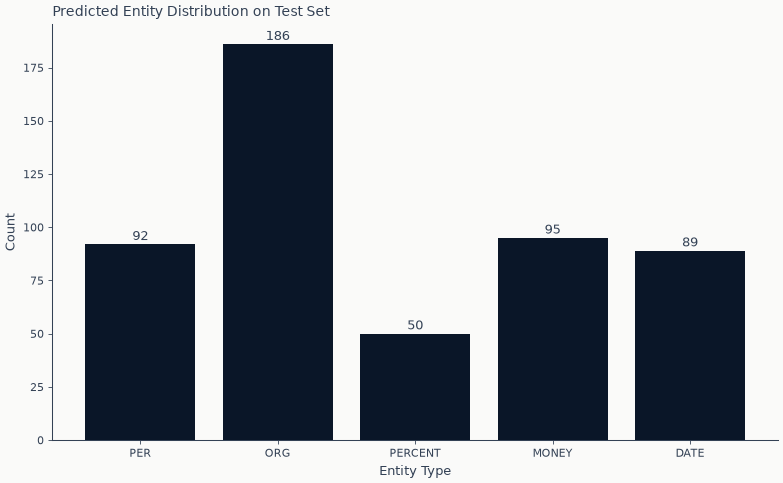

In [14]:
# Entity distribution visualization

# Get predictions on test set
predictions = trainer.predict(tokenized_dataset["test"])
pred_labels = np.argmax(predictions.predictions, axis=2)

# Count entity types (excluding O and -100)
entity_counts = Counter()
for pred_seq, label_seq in zip(pred_labels, predictions.label_ids, strict=False):
    for p, l in zip(pred_seq, label_seq, strict=False):
        if l != -100 and id2label[p] != "O":
            entity_type = id2label[p].split("-")[1]
            entity_counts[entity_type] += 1

fig, ax = plt.subplots(figsize=(8, 5))
types = list(entity_counts.keys())
counts = list(entity_counts.values())

bars = ax.bar(types, counts, color="#0a1628")
ax.set_xlabel("Entity Type")
ax.set_ylabel("Count")
ax.set_title("Predicted Entity Distribution on Test Set")

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
    )

plt.tight_layout()
plt.show()

## Downstream Feature Engineering: From Entities to ML Features

NER output is only useful if we convert it to structured features for ML models.
This section demonstrates how to create quantitative features from entity extractions.

In [15]:
# ============================================================================
# DOWNSTREAM FEATURE EXAMPLE: Entity Counts as Features
# ============================================================================
# This bridges NER to feature engineering for ML models.

print("\n" + "=" * 70)
print("DOWNSTREAM FEATURE ENGINEERING")
print("=" * 70)


def extract_entity_features(text: str) -> dict:
    """
    Extract NER-based features from text for ML modeling.

    Returns:
        Dictionary of features derived from extracted entities.
    """
    entities = extract_entities(text)

    # Initialize feature counts
    features = {
        "n_org": 0,  # Number of organizations mentioned
        "n_money": 0,  # Number of monetary values
        "n_date": 0,  # Number of dates
        "n_per": 0,  # Number of people
        "n_percent": 0,  # Number of percentages
        "n_total_entities": 0,  # Total entity count
        "has_money": 0,  # Binary: mentions money?
        "has_multiple_orgs": 0,  # Binary: >1 org mentioned?
    }

    for _, etype in entities:
        features["n_total_entities"] += 1
        if etype == "ORG":
            features["n_org"] += 1
        elif etype == "MONEY":
            features["n_money"] += 1
        elif etype == "DATE":
            features["n_date"] += 1
        elif etype == "PER":
            features["n_per"] += 1
        elif etype == "PERCENT":
            features["n_percent"] += 1

    # Derived features
    features["has_money"] = 1 if features["n_money"] > 0 else 0
    features["has_multiple_orgs"] = 1 if features["n_org"] > 1 else 0

    return features


# Demo on sample financial texts
sample_texts = [
    "Apple Inc. reported quarterly revenue of $94.8 billion in January 2024.",
    "Goldman Sachs CEO David Solomon announced a 15% increase in dividends.",
    "The Federal Reserve raised interest rates by 0.25% following inflation data.",
    "Tesla shares rose 5% after Elon Musk announced new factory plans.",
]

import polars as pl

feature_records = []
for text in sample_texts:
    features = extract_entity_features(text)
    features["text"] = text[:50] + "..." if len(text) > 50 else text
    feature_records.append(features)

features_df = pl.DataFrame(feature_records).select(
    ["text", "n_org", "n_money", "n_per", "n_percent", "has_money", "n_total_entities"]
)
features_df


DOWNSTREAM FEATURE ENGINEERING


text,n_org,n_money,n_per,n_percent,has_money,n_total_entities
str,i64,i64,i64,i64,i64,i64
"""Apple Inc. reported quarterly revenue of $94.8 bil…",1,2,0,0,1,4
"""Goldman Sachs CEO David Solomon announced a 15% in…",1,0,1,1,0,3
"""The Federal Reserve raised interest rates by 0.25%…",1,0,0,2,0,3
"""Tesla shares rose 5% after Elon Musk announced new…",2,0,1,1,0,4


## Key Takeaways

1. **Token classification** extends Transformers from document-level to
   word-level predictions, enabling structured extraction from unstructured text.

2. **BIO tagging** handles multi-word entities: B-ORG marks the beginning,
   I-ORG continues, O marks non-entities.

3. **Subword alignment** is critical: when tokenizers split words, only the
   first subword receives the label; others get -100 (ignored in loss).

4. Financial NER enables **automated extraction** of companies, amounts,
   dates, and people from earnings calls, filings, and news.

5. **Entity counts as features**: The number and types of entities in a document
   create structured features for ML models, complementing sentiment analysis.